In [3]:
!pip install -q datasets transformers matplotlib seaborn pandas

In [4]:
# ---------------- 代码块 1：加载与切分数据集 ----------------
from datasets import load_dataset
import pandas as pd

print("正在从 Hugging Face 加载 IMDB 数据集...")
# load_dataset 会自动下载并切分好 train（训练集）和 test（测试集）
# IMDB 是一个经典的二分类数据集：0代表负面(Negative)，1代表正面(Positive)
dataset = load_dataset("imdb")

# 打印数据集的基本信息
print("\n数据集结构概览：")
print(dataset)

# 为了方便进行第二步的可视化分析，我们将训练集转换为 Pandas DataFrame 格式
df_train = dataset['train'].to_pandas()
df_test = dataset['test'].to_pandas()

print(f"\n成功加载！训练集样本数: {len(df_train)}，测试集样本数: {len(df_test)}")
# 展示前3条数据看看长什么样
display(df_train.head(3))

正在从 Hugging Face 加载 IMDB 数据集...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


数据集结构概览：
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

成功加载！训练集样本数: 25000，测试集样本数: 25000


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0


/tmp/ipykernel_4692/1588992273.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_train, ax=axes[0], palette="pastel")


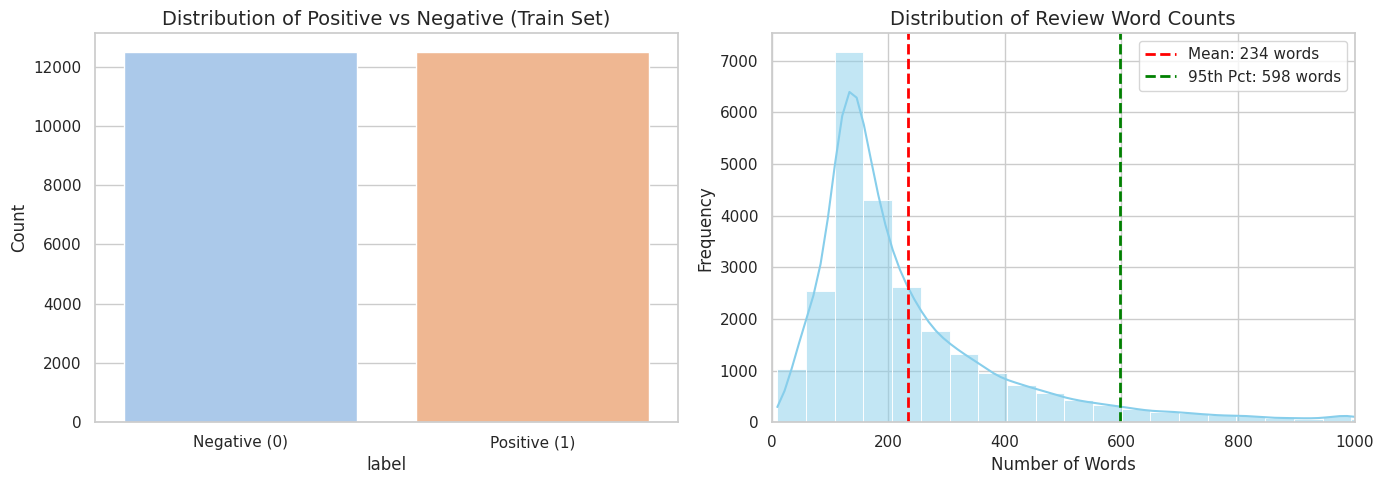

【分析结论】：
1. 样本完全平衡。
2. 95%的评论单词数都在 598 以下。虽然有些超长评论，但考虑到计算资源，我们下一步将采用预训练模型的标准最大长度 512 进行截断。


In [5]:
# ---------------- 代码块 2：探索性数据分析与图表绘制 ----------------
import matplotlib.pyplot as plt
import seaborn as sns

# 设置美观的绘图风格（让报告里的图看起来更专业）
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 尽量显示中文，如果Colab缺字体可能显示方块，但不影响英文

# 创建一个 1x2 的画板，一次性画两张图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 图表 1：正负样本比例图 ---
# 检查数据是否平衡（IMDB 是完美的 50% 对 50%）
sns.countplot(x='label', data=df_train, ax=axes[0], palette="pastel")
axes[0].set_title('Distribution of Positive vs Negative (Train Set)', fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Negative (0)', 'Positive (1)'])
axes[0].set_ylabel('Count')

# --- 图表 2：文本长度分布直方图 ---
# 统计每条评论的单词数量
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))

sns.histplot(df_train['word_count'], bins=50, kde=True, color='skyblue', ax=axes[1])
# 计算平均值和95%分位数，并画垂直参考线
mean_len = df_train['word_count'].mean()
p95_len = df_train['word_count'].quantile(0.95)

axes[1].axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_len:.0f} words')
axes[1].axvline(p95_len, color='green', linestyle='dashed', linewidth=2, label=f'95th Pct: {p95_len:.0f} words')

axes[1].set_title('Distribution of Review Word Counts', fontsize=14)
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 1000) # 大部分都在1000词以内，限制X轴让图更好看
axes[1].legend()

# 紧凑布局并显示
plt.tight_layout()
plt.show()

print(f"【分析结论】：\n1. 样本完全平衡。\n2. 95%的评论单词数都在 {p95_len:.0f} 以下。虽然有些超长评论，但考虑到计算资源，我们下一步将采用预训练模型的标准最大长度 512 进行截断。")

In [6]:
# ---------------- 代码块 3：数据预处理与 Tokenization ----------------
from transformers import AutoTokenizer

print("正在下载 DistilBERT 的分词器 (Tokenizer)...")
# 我们选用轻量级的 distilbert 作为基座模型
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 定义一个分词函数
def tokenize_function(examples):
    # padding="max_length": 短句子用 0 补齐
    # truncation=True: 长句子直接切断
    # max_length=512: Transformer 模型的经典输入长度上限
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

print("正在对整个数据集（25000条训练集 + 25000条测试集）进行批量分词...")
print("(利用 batched=True，这个过程只需大约十几秒~几十秒)")

# 使用 map 函数批量应用分词，batched=True 可以大幅加速
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 打印分词后的结果对比
print("\n✅ 分词完成！")
print("原始数据包含的列:", dataset["train"].column_names)
print("分词后新增的列 (这些是喂给模型的张量特征):", tokenized_datasets["train"].column_names)

# 展示第一条数据被转化后的前20个 Token ID
sample_ids = tokenized_datasets["train"][0]["input_ids"][:20]
print("\n【直观演示】:")
print(f"计算机看到的不再是英文，而是数字 ID (前 20 个): {sample_ids}")
print(f"这些 ID 还原成 Token 是这样的: {tokenizer.convert_ids_to_tokens(sample_ids)}")

正在下载 DistilBERT 的分词器 (Tokenizer)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

正在对整个数据集（25000条训练集 + 25000条测试集）进行批量分词...
(利用 batched=True，这个过程只需大约十几秒~几十秒)


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]


✅ 分词完成！
原始数据包含的列: ['text', 'label']
分词后新增的列 (这些是喂给模型的张量特征): ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

【直观演示】:
计算机看到的不再是英文，而是数字 ID (前 20 个): [101, 1045, 12524, 1045, 2572, 8025, 1011, 3756, 2013, 2026, 2678, 3573, 2138, 1997, 2035, 1996, 6704, 2008, 5129, 2009]
这些 ID 还原成 Token 是这样的: ['[CLS]', 'i', 'rented', 'i', 'am', 'curious', '-', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it']


In [7]:
# ---------------- 代码块 4：模型加载与评估指标定义 ----------------
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score

# 1. 检查 GPU 是否就绪
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")
if device.type != 'cuda':
    print("⚠️ 警告：当前未使用 GPU！训练将会极其缓慢。请检查 Colab 运行时设置。")

print("\n正在下载带有序列分类头 (Sequence Classification Head) 的 DistilBERT 模型...")
# num_labels=2 表示这是一个二分类任务 (0=负面, 1=正面)
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)
model.to(device)

# 2. 定义评估指标函数 (Trainer 会在验证/测试时调用)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # 模型输出的是 Logits (未经过 Softmax 的概率)，我们取最大值所在的索引作为预测结果
    predictions = np.argmax(logits, axis=-1)

    # 计算准确率和 F1 分数
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')

    return {
        "accuracy": acc,
        "f1": f1
    }

print("✅ 模型架构实例化成功！评估函数 (Accuracy & F1) 已定义。")

当前使用的计算设备: cuda

正在下载带有序列分类头 (Sequence Classification Head) 的 DistilBERT 模型...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ 模型架构实例化成功！评估函数 (Accuracy & F1) 已定义。


In [8]:
# ---------------- 代码块 5：配置超参数与启动训练 ----------------
from transformers import TrainingArguments, Trainer

print("正在配置微调超参数 (Hyperparameters)...")

# 1. 设定训练参数
training_args = TrainingArguments(
    output_dir="./results",               # 模型预测结果和检查点的保存路径
    learning_rate=2e-5,                   # 学习率：预训练模型微调通常使用较小的学习率 (如 2e-5 到 5e-5)
    per_device_train_batch_size=16,       # 训练时的批次大小 (16 是 T4 显存的安全值)
    per_device_eval_batch_size=16,        # 评估时的批次大小
    num_train_epochs=2,                   # 训练轮数：微调 2-3 轮通常就足够收敛了
    weight_decay=0.01,                    # 权重衰减：用于防止过拟合
    eval_strategy="epoch",                # 评估策略：每个 epoch 结束后在测试集上评估一次
    save_strategy="epoch",                # 保存策略：每个 epoch 结束后保存一次模型
    logging_strategy="steps",             # 日志记录策略：每多少步记录一次 Loss
    logging_steps=100,                    # 每 100 步记录一次训练损失，方便后面画 Loss 曲线
    load_best_model_at_end=True,          # 训练结束后自动加载验证集上表现最好的模型权重
    report_to="none"                      # 暂时不将日志上报到第三方监控平台（如 WandB）
)

# 2. 实例化 Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],    # 喂入我们在阶段二处理好的训练集
    eval_dataset=tokenized_datasets["test"],      # 喂入阶段二处理好的测试集作为评估
    compute_metrics=compute_metrics               # 传入刚才定义的评估函数
)

# 3. 开始模型微调 (Fine-tuning)
print("🚀 开始模型微调！请耐心等待训练完成 (T4 GPU 大约需要 15-20 分钟)...")
train_result = trainer.train()

print("\n🎉 训练圆满结束！")

正在配置微调超参数 (Hyperparameters)...
🚀 开始模型微调！请耐心等待训练完成 (T4 GPU 大约需要 15-20 分钟)...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.219787,0.215888,0.915880,0.912159
2,0.129018,0.235067,0.930320,0.930548


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



🎉 训练圆满结束！


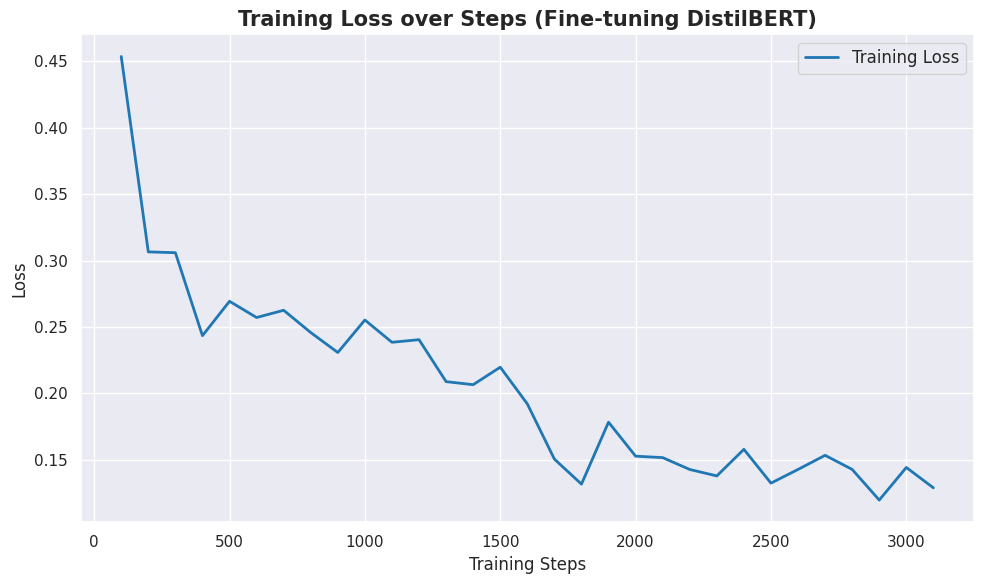

✅ 训练 Loss 曲线绘制完毕！请将此图保存并插入到报告预留位置。


In [9]:
# ---------------- 代码块 6：绘制训练 Loss 曲线 ----------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 从 trainer 的内部状态中提取记录的日志
log_history = trainer.state.log_history

# 过滤出包含 'loss' (Training Loss) 的记录，并提取对应的步数 (step)
train_steps = []
train_loss = []

for entry in log_history:
    if 'loss' in entry and 'step' in entry:
        train_steps.append(entry['step'])
        train_loss.append(entry['loss'])

# 绘制 Loss 下降曲线
plt.figure(figsize=(10, 6))
sns.set_theme(style="darkgrid")
plt.plot(train_steps, train_loss, label='Training Loss', color='#1f77b4', linewidth=2)

plt.title('Training Loss over Steps (Fine-tuning DistilBERT)', fontsize=15, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)

# 让曲线更平滑一点，好看
plt.tight_layout()
plt.show()

print("✅ 训练 Loss 曲线绘制完毕！请将此图保存并插入到报告预留位置。")

正在测试集上进行全量预测 (闭卷考试)，请稍候 (约 1-2 分钟)...


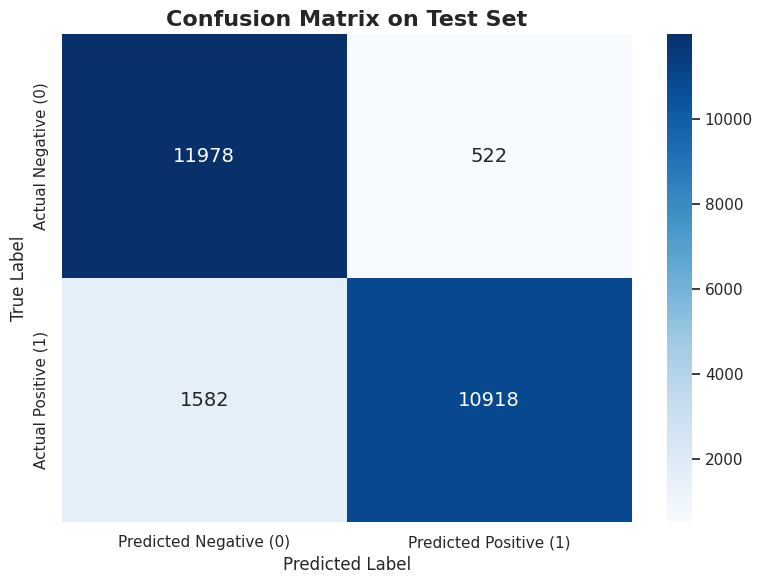

✅ 混淆矩阵绘制完成！请保存图片。

🧐 开始人工错误分析 (Error Analysis)

模型总共预测错了 2104 条数据。
其中：假阳性 (FP, 烂片被当成好片) 有 522 条。
      假阴性 (FN, 好片被当成烂片) 有 1582 条。

-------------------- 典型错误：假阳性 (实际负面 -> 预测正面) --------------------
案例 1:
[文本]: First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!...

案例 2:
[文本]: Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His fa

In [12]:
# ---------------- 代码块 7：混淆矩阵与错误案例提取 ----------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("正在测试集上进行全量预测 (闭卷考试)，请稍候 (约 1-2 分钟)...")
# 1. 获取测试集上的预测结果
predictions_output = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

# 2. 绘制高颜值混淆矩阵
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))
# annot=True 会在格子里写上具体的数字，fmt='d' 保证是整数格式
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'],
            annot_kws={"size": 14}) # 调整数字大小

plt.title('Confusion Matrix on Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("✅ 混淆矩阵绘制完成！请保存图片。")

# 3. 提取典型错误案例 (错题本)
print("\n" + "="*50)
print("🧐 开始人工错误分析 (Error Analysis)")
print("="*50)

# 找到预测错误的索引
errors = np.where(predictions != true_labels)[0]

# 区分假阳性 (False Positive: 实际是负面，模型猜成了正面)
# 和假阴性 (False Negative: 实际是正面，模型猜成了负面)
fp_indices = [i for i in errors if true_labels[i] == 0 and predictions[i] == 1]
fn_indices = [i for i in errors if true_labels[i] == 1 and predictions[i] == 0]

print(f"\n模型总共预测错了 {len(errors)} 条数据。")
print(f"其中：假阳性 (FP, 烂片被当成好片) 有 {len(fp_indices)} 条。")
print(f"      假阴性 (FN, 好片被当成烂片) 有 {len(fn_indices)} 条。")

# 打印 2 个假阳性案例和 2 个假阴性案例供报告使用
print("\n" + "-"*20 + " 典型错误：假阳性 (实际负面 -> 预测正面) " + "-"*20)
for i in range(min(2, len(fp_indices))):
    # 修复错误：显式转换为 Python int，因为 datasets 不支持 numpy.int64 索引
    idx = int(fp_indices[i])
    text = dataset["test"]["text"][idx]
    # 截取前 800 个字符展示，避免太长
    print(f"案例 {i+1}:\n[文本]: {text[:800]}...\n")

print("\n" + "-"*20 + " 典型错误：假阴性 (实际正面 -> 预测负面) " + "-"*20)
for i in range(min(2, len(fn_indices))):
    # 修复错误：显式转换为 Python int
    idx = int(fn_indices[i])
    text = dataset["test"]["text"][idx]
    print(f"案例 {i+1}:\n[文本]: {text[:800]}...\n")

In [13]:
# ---------------- 代码块 8：构建并启动 Gradio 交互式 Web 网页 ----------------
# 安装极简 Web 框架 gradio
!pip install -q gradio

import gradio as gr
from transformers import pipeline

print("正在将微调后的模型封装为推理管线 (Pipeline)...")
# 利用 pipeline 将我们内存中训练好的 model 和 tokenizer 封装起来，准备部署
# device=0 表示使用当前 T4 GPU 进行极速推理
sentiment_pipeline = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

# 定义前端网页点击“分析”按钮时触发的函数
def analyze_sentiment(text):
    if not text.strip():
        return "请输入内容", ""

    # 调用模型进行预测
    result = sentiment_pipeline(text)[0]

    # 将 LABEL_0 / LABEL_1 转换为人类可读的文字
    if result['label'] == 'LABEL_1':
        label_text = "😊 正面评价 (Positive)"
    else:
        label_text = "😞 负面评价 (Negative)"

    # 将分数转化为百分比
    confidence = f"{result['score'] * 100:.2f}%"

    return label_text, confidence

print("正在启动 Web UI... 请点击下方出现的 Public URL 链接进入网页！")

# 构建 Gradio 网页界面
demo = gr.Interface(
    fn=analyze_sentiment,
    inputs=gr.Textbox(lines=5, placeholder="Please enter an English movie review here (e.g., This movie is absolutely fantastic!)...", label="输入英文影评"),
    outputs=[
        gr.Text(label="🤖 模型预测情感倾向"),
        gr.Text(label="📊 模型置信度 (Confidence Score)")
    ],
    title="🎬 基于 DistilBERT 的电影评论情感分析系统",
    description="这是一个由预训练大语言模型微调而成的 AI 演示系统。请输入一段英文文本，模型将自动判断其是好评还是差评。",
    theme=gr.themes.Soft() # 使用柔和的主题
)

# share=True 会生成一个公网链接 (类似 https://xxxx.gradio.live)
demo.launch(share=True)

正在将微调后的模型封装为推理管线 (Pipeline)...
正在启动 Web UI... 请点击下方出现的 Public URL 链接进入网页！
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://38126347c0ebf6126e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
